# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Zepjen Cheong 



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [ ]:
## Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. Business Understanding
Goal: HDB buyers and sellers may find it difficult to estimate a fair resale price because the price depends on many factors such as town, flat type, floor area, storey level, flat model, remaining lease, and sale period.

The goal of this project is to build a machine learning model that predicts the **resale price** of a HDB flat using past resale transaction data and other factor.

This is a **regression** problem because the target variable, `resale_price`, is a continuous numerical value in dollars.


# 2. Data Understanding

## 2.1 Load dataset

In [ ]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "hdb.csv"
df = pd.read_csv(FILE_PATH)


## 2.2 Summary Statistics

In [ ]:
## Understand the type of variable for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 207875 entries, 0 to 207874
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                207875 non-null  str    
 1   town                 207875 non-null  str    
 2   flat_type            207875 non-null  str    
 3   block                207875 non-null  str    
 4   street_name          207875 non-null  str    
 5   storey_range         207875 non-null  str    
 6   floor_area_sqm       207875 non-null  float64
 7   flat_model           207875 non-null  str    
 8   lease_commence_date  207875 non-null  int64  
 9   remaining_lease      207875 non-null  str    
 10  resale_price         207875 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 32.1 MB


In [ ]:
## Check for missing data
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values


month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [ ]:
## Describe data distribution
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 303


There are 303 duplicate rows in the dataset. These duplicate records may cause the model to learn repeated transactions and create biased results. Since the number of duplicates is small compared to the full dataset, I will remove them before training the model.

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check the new dataset size
print("Dataset shape after removing duplicates:", df.shape)
print("Number of duplicate rows after cleaning:", df.duplicated().sum())

Dataset shape after removing duplicates: (207572, 11)
Number of duplicate rows after cleaning: 0


## Reduce Dataset Scope

The original dataset has more than 200,000 rows, which is too broad for this project. To make the machine learning problem more focused and easier to explain, I will only use selected HDB towns.

I selected a few estates so that the model predicts resale prices within a smaller and clearer market segment instead of trying to cover the whole of Singapore.

In [ ]:
# Check how many rows each town has
df['town'].value_counts()

town
SENGKANG           17065
PUNGGOL            15198
WOODLANDS          14758
YISHUN             14168
TAMPINES           14086
JURONG WEST        13764
BEDOK              10849
HOUGANG            10437
CHOA CHU KANG       9428
ANG MO KIO          8504
BUKIT BATOK         8495
BUKIT MERAH         7957
BUKIT PANJANG       7467
TOA PAYOH           6575
KALLANG/WHAMPOA     6338
SEMBAWANG           6072
PASIR RIS           5997
QUEENSTOWN          5672
GEYLANG             5101
CLEMENTI            4609
JURONG EAST         4243
SERANGOON           3715
BISHAN              3654
CENTRAL AREA        1636
MARINE PARADE       1272
BUKIT TIMAH          512
Name: count, dtype: int64

I only choose These 3 Towns as they are all in the central region

In [ ]:
# Select only a few HDB towns to reduce project scope
selected_towns = ['TOA PAYOH', 'ANG MO KIO', 'BISHAN']

df = df[df['town'].isin(selected_towns)]

print("New dataset shape:", df.shape)
print(df['town'].value_counts())

New dataset shape: (18733, 11)
town
ANG MO KIO    8504
TOA PAYOH     6575
BISHAN        3654
Name: count, dtype: int64


After filtering, the dataset now contains only resale transactions from Toa Payoh, Ang Mo Kio, and Bishan. This reduces the dataset size while still keeping enough data for machine learning.

## 2.3 Data Visualization

### 2.3.1.1 Understanding distribution of target

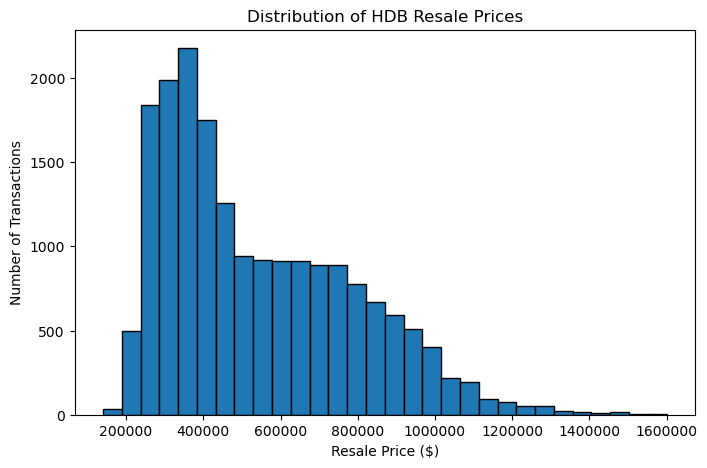

In [ ]:
## Understanding distribution of target
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['resale_price'], bins=30, edgecolor='black')
plt.title('Distribution of HDB Resale Prices')
plt.xlabel('Resale Price ($)')
plt.ylabel('Number of Transactions')

# Make x-axis show normal dollar values instead of 1e6
plt.ticklabel_format(style='plain', axis='x')

plt.show()

The histogram shows that most HDB resale prices are concentrated around the $300,000 to $450,000 range. As the resale price increases, the number of transactions decreases. The graph is right-skewed, which means there are some higher-priced flats above $1 million. These expensive flats may be caused by factors such as larger floor area, better location, higher storey, or newer remaining lease. This shows that resale_price has a wide range, so features such as town, flat type, floor area, lease, and storey range are likely important for prediction.

### 2.3.1.2 Understanding distribution of features

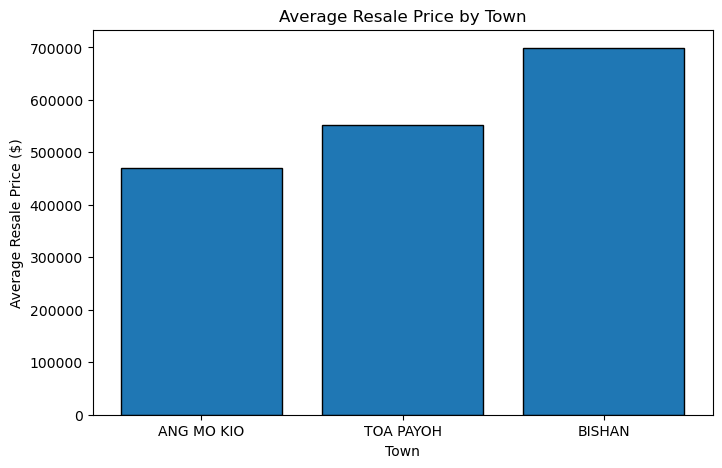

In [ ]:
town_avg_price = df.groupby('town')['resale_price'].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(town_avg_price.index, town_avg_price.values, edgecolor='black')
plt.title('Average Resale Price by Town')
plt.xlabel('Town')
plt.ylabel('Average Resale Price ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

The bar chart shows the average HDB resale price for each selected town. Bishan has the highest average resale price, followed by Toa Payoh and Ang Mo Kio. This suggests that location has an important relationship with resale price. Therefore, the town column should be kept as a feature for the machine learning model.

However, the average price may also be affected by other factors such as flat type, floor area, remaining lease, and storey range. Therefore, more visualisations are needed to understand the dataset better.

### 2.3.2 Understanding relationship between variables

### Average Resale Price by Flat Type

This visualisation shows whether larger flat types tend to have higher resale prices.

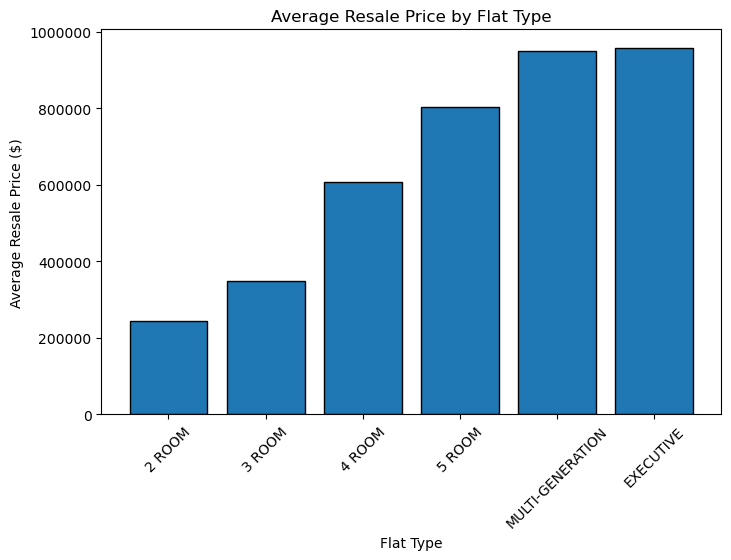

In [ ]:
flat_type_avg_price = df.groupby('flat_type')['resale_price'].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(flat_type_avg_price.index, flat_type_avg_price.values, edgecolor='black')
plt.title('Average Resale Price by Flat Type')
plt.xlabel('Flat Type')
plt.ylabel('Average Resale Price ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.show()


The bar chart shows that average resale price increases as the flat type becomes larger. 2 ROOM and 3 ROOM flats have the lowest average resale prices, while EXECUTIVE and MULTI-GENERATION flats have the highest average resale prices.

This suggests that flat type has a strong relationship with resale price. Larger flat types usually have more space, so buyers are willing to pay more. Therefore, flat_type should be included as an important feature in the machine learning model.

### Relationship Between Floor Area and Resale Price

This visualisation shows whether flats with larger floor area tend to have higher resale prices.

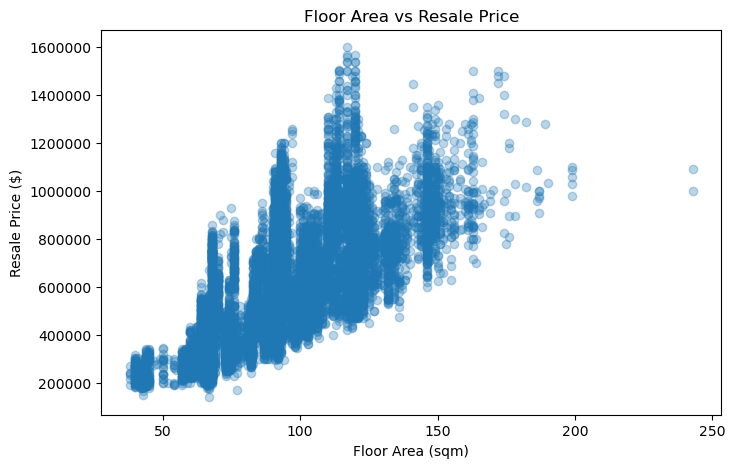

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['floor_area_sqm'], df['resale_price'], alpha=0.3)
plt.title('Floor Area vs Resale Price')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

The scatter plot shows a positive relationship between floor area and resale price. In general, flats with larger floor area tend to have higher resale prices.

However, the points are spread out, which shows that floor area alone cannot fully explain resale price. Other factors such as town, flat type, storey range, and remaining lease may also affect the final resale price. This means the machine learning model should use multiple features instead of only floor area.

### Average Resale Price by Storey Range

This visualisation shows whether flats on higher floors tend to have higher resale prices.

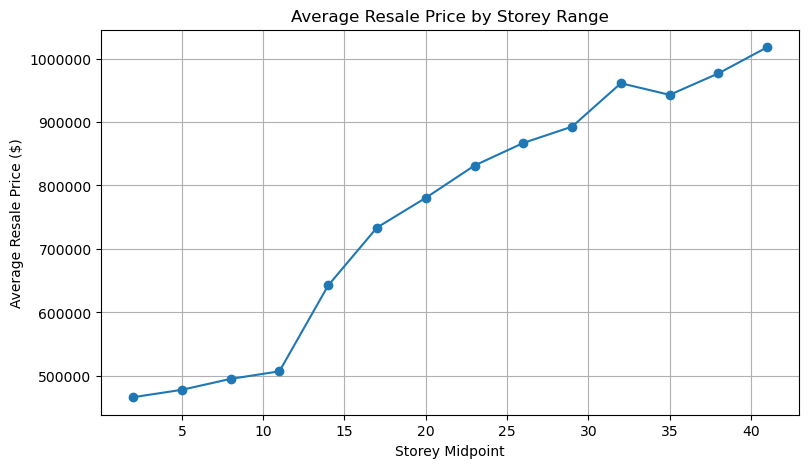

In [ ]:
# Create a numerical midpoint for storey_range
# Example: '04 TO 06' becomes (4 + 6) / 2 = 5
df['storey_mid'] = df['storey_range'].str.extract(r'(\d+) TO (\d+)').astype(int).mean(axis=1)

storey_avg_price = df.groupby('storey_mid')['resale_price'].mean().sort_index()

plt.figure(figsize=(9, 5))
plt.plot(storey_avg_price.index, storey_avg_price.values, marker='o')
plt.title('Average Resale Price by Storey Range')
plt.xlabel('Storey Midpoint')
plt.ylabel('Average Resale Price ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()

The line chart shows that average resale price generally increases as the storey midpoint increases. Flats on higher floors tend to have higher average resale prices compared to lower-floor flats.

This suggests that storey range has a relationship with resale price and should be included in the machine learning model. However, there are small fluctuations at higher storeys, which may be caused by fewer transactions or other factors such as flat type, town, and floor area.

### Relationship Between Remaining Lease and Resale Price

This visualisation shows whether flats with more remaining lease tend to have higher resale prices.

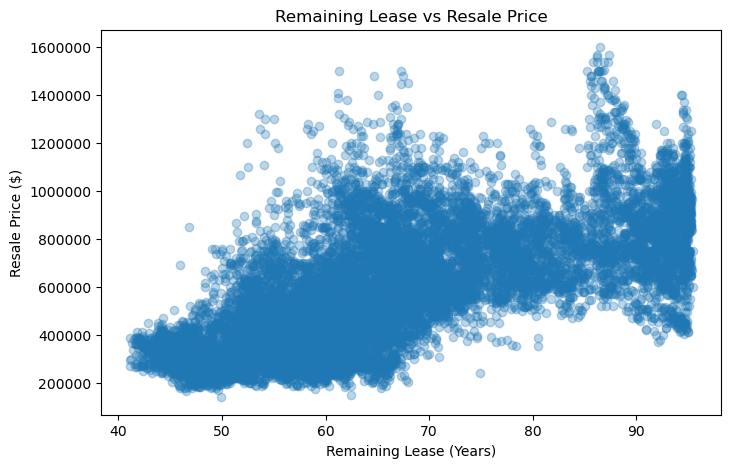

In [ ]:
# Convert remaining_lease from text into number of years
# Example: "61 years 04 months" becomes about 61.33 years

def convert_lease_to_years(lease):
    parts = lease.split()
    years = 0
    months = 0
    
    if 'years' in parts:
        years = int(parts[parts.index('years') - 1])
    elif 'year' in parts:
        years = int(parts[parts.index('year') - 1])
        
    if 'months' in parts:
        months = int(parts[parts.index('months') - 1])
    elif 'month' in parts:
        months = int(parts[parts.index('month') - 1])
        
    return years + months / 12

df['remaining_lease_years'] = df['remaining_lease'].apply(convert_lease_to_years)

plt.figure(figsize=(8, 5))
plt.scatter(df['remaining_lease_years'], df['resale_price'], alpha=0.3)
plt.title('Remaining Lease vs Resale Price')
plt.xlabel('Remaining Lease (Years)')
plt.ylabel('Resale Price ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

The scatter plot shows that flats with higher remaining lease generally tend to have higher resale prices. This suggests that remaining lease is an important factor because buyers may be willing to pay more for flats with more years left.

However, the points are widely spread out, meaning remaining lease alone cannot fully explain resale price. Other factors such as town, flat type, floor area, and storey range also affect the final price. Therefore, remaining_lease_years should be included as one of the features in the machine learning model.


### Correlation Between Numerical Features

This visualisation shows how strongly the numerical features are related to resale price.

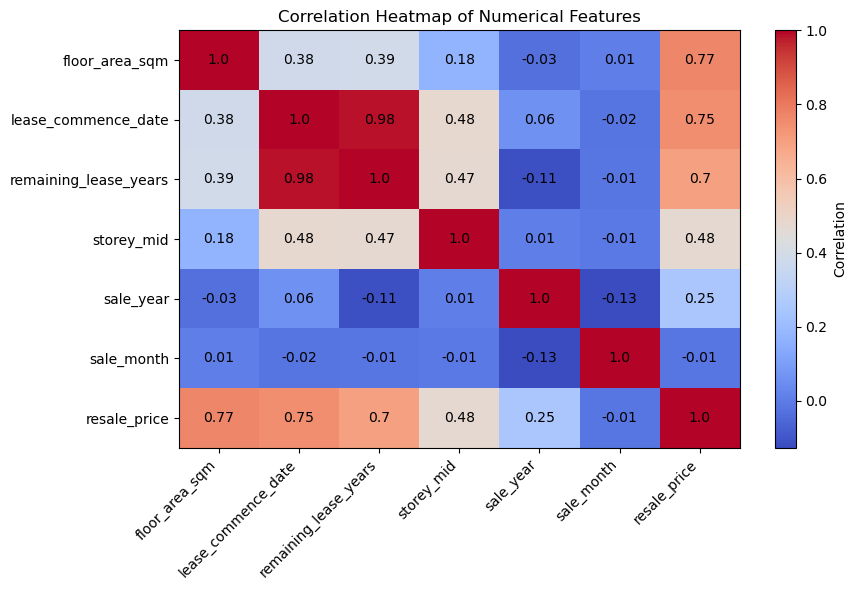

In [ ]:
# Create sale_year and sale_month from the month column
df['sale_year'] = df['month'].str[:4].astype(int)
df['sale_month'] = df['month'].str[5:7].astype(int)

# Select numerical columns for correlation
numeric_cols = [
    'floor_area_sqm',
    'lease_commence_date',
    'remaining_lease_years',
    'storey_mid',
    'sale_year',
    'sale_month',
    'resale_price'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlation')

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)

# Add correlation values inside the boxes
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha='center', va='center')

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

The correlation heatmap shows the relationship between numerical features and resale_price.

floor_area_sqm has the strongest positive correlation with resale_price at 0.77. This means larger flats generally have higher resale prices.

lease_commence_date and remaining_lease_years also have strong positive relationships with resale_price, with correlations of 0.75 and 0.70 respectively. This suggests that newer flats or flats with more remaining lease tend to sell for higher prices.

storey_mid has a moderate positive correlation of 0.48, which means higher-floor flats may have higher resale prices.

sale_month has almost no relationship with resale_price, so it is likely not very useful for prediction.

lease_commence_date and remaining_lease_years are highly correlated with each other at 0.98. To avoid using two very similar features, I will keep remaining_lease_years because it is easier to understand from a buyer’s perspective.

# 3. Data Preparation


## 3.1 Feature Engineering and Feature Selection Plan
The dataset has already been cleaned, filtered to the selected towns, and given several engineered numerical features.

A controlled feature-removal experiment will be conducted to determine which input features are useful for predicting resale price.

First, a control model will be trained using the complete candidate feature set. After that, one feature will be removed at a time and the model will be retrained.

To keep the experiment fair, every model will use:

- the same training and testing records
- the same machine learning algorithm
- the same model hyperparameters
- the same preprocessing method
- the same random state

Only the selected input features will change between experiments. Model performance will be compared using RMSE, MAE and R².



In [ ]:
# Check current columns after cleaning, scope filtering, and feature engineering
df.columns


Index(['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date',
       'remaining_lease', 'resale_price', 'storey_mid',
       'remaining_lease_years', 'sale_year', 'sale_month'],
      dtype='str')

The available columns include both original variables and engineered variables.

Some original columns contain similar information to the engineered columns. For example:

- `month` is represented by `sale_year` and `sale_month`
- `storey_range` is represented by `storey_mid`
- `remaining_lease` is represented by `remaining_lease_years`

The original duplicate columns will not be included in the candidate feature set because their information is already represented in a more model-friendly numerical form.

Other columns, such as `block` and `street_name`, will initially remain in the control model. Their usefulness will be tested during the feature-removal experiment rather than assumed beforehand.

## 3.1 Candidate Features and Controlled Experiment Plan

The candidate feature set contains the variables that will be used by the control model. Original columns that duplicate the engineered features are excluded.

The target variable is `resale_price`, as the objective is to predict the resale price of an HDB flat.

In [ ]:
# Complete candidate feature set for the control model
candidate_features = [
    'town',
    'flat_type',
    'block',
    'street_name',
    'flat_model',
    'floor_area_sqm',
    'remaining_lease_years',
    'storey_mid',
    'sale_year',
    'sale_month'
]

# Target variable
target = 'resale_price'

print("Number of candidate features:", len(candidate_features))
print("Candidate features:", candidate_features)
print("Target:", target)

# Check the selected features and target
df[candidate_features + [target]].head()

# Check data types and missing values
feature_check = pd.DataFrame({
    'Data Type': df[candidate_features + [target]].dtypes,
    'Missing Values': df[candidate_features + [target]].isnull().sum(),
    'Unique Values': df[candidate_features + [target]].nunique()
})

feature_check

Number of candidate features: 10
Candidate features: ['town', 'flat_type', 'block', 'street_name', 'flat_model', 'floor_area_sqm', 'remaining_lease_years', 'storey_mid', 'sale_year', 'sale_month']
Target: resale_price


,Data Type,Missing Values,Unique Values
town,str,0,3
flat_type,str,0,6
block,str,0,580
street_name,str,0,48
flat_model,str,0,13
floor_area_sqm,float64,0,139
remaining_lease_years,float64,0,654
storey_mid,float64,0,14
sale_year,int64,0,9
sale_month,int64,0,12


## 3.2 Separating Input Features and Target
The following candidate features will be used as the input variables, represented by `X`. Original columns that duplicate the engineered features are excluded.

The target variable, represented by `y`, is `resale_price`, as the objective is to predict the continuous resale price of an HDB flat.


In [ ]:
# Complete candidate feature set
candidate_features = [
    'town',
    'flat_type',
    'block',
    'street_name',
    'flat_model',
    'floor_area_sqm',
    'remaining_lease_years',
    'storey_mid',
    'sale_year',
    'sale_month'
]

# Target variable
target = 'resale_price'

# Separate input features and target variable
X = df[candidate_features]
y = df[target]

print("Number of candidate features:", len(candidate_features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of candidate features: 10
X shape: (18733, 10)
y shape: (18733,)


## 3.3 Identifying Categorical Features
Categorical features contain labels or groups rather than continuous numerical measurements. These features must be identified before modelling because most machine learning models cannot directly process text values.

The data types and number of unique values in each input feature will be inspected to determine which features require one-hot encoding.

In [ ]:
# Check the data type and number of unique values for each input feature
feature_summary = pd.DataFrame({
    'Data Type': X.dtypes,
    'Number of Unique Values': X.nunique()
})

display(feature_summary)


# Automatically identify categorical and numerical features
categorical_features = X.select_dtypes(
    include=['object', 'category', 'string']
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=['object', 'category', 'string']
).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

# Inspect the unique values in each categorical feature
for feature in categorical_features:
    unique_values = X[feature].dropna().unique()
    unique_count = X[feature].nunique()

    print(f"\nFeature: {feature}")
    print(f"Number of unique values: {unique_count}")
    print("Unique values:", unique_values[:20])

    if unique_count > 20:
        print("(Only the first 20 unique values are shown.)")

,Data Type,Number of Unique Values
town,str,3
flat_type,str,6
block,str,580
street_name,str,48
flat_model,str,13
floor_area_sqm,float64,139
remaining_lease_years,float64,654
storey_mid,float64,14
sale_year,int64,9
sale_month,int64,12


Categorical features: ['town', 'flat_type', 'block', 'street_name', 'flat_model']
Numerical features: ['floor_area_sqm', 'remaining_lease_years', 'storey_mid', 'sale_year', 'sale_month']

Feature: town
Number of unique values: 3
Unique values: <ArrowStringArray>
['ANG MO KIO', 'BISHAN', 'TOA PAYOH']
Length: 3, dtype: str

Feature: flat_type
Number of unique values: 6
Unique values: <ArrowStringArray>
['2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE', 'MULTI-GENERATION']
Length: 6, dtype: str

Feature: block
Number of unique values: 580
Unique values: <ArrowStringArray>
['406', '108', '602', '465', '601', '150', '447', '218', '571', '534', '233',
 '235', '219', '536', '230', '570', '624', '441', '625', '119']
Length: 20, dtype: str
(Only the first 20 unique values are shown.)

Feature: street_name
Number of unique values: 48
Unique values: <ArrowStringArray>
['ANG MO KIO AVE 10',  'ANG MO KIO AVE 4',  'ANG MO KIO AVE 5',
  'ANG MO KIO AVE 1',  'ANG MO KIO AVE 3',  'ANG MO KIO AVE 9',

The categorical features identified are town, flat_type, block, street_name, and flat_model. Since these features contain text-based categories, one-hot encoding will be applied before modelling.

block has the highest cardinality, with 580 unique values. This may substantially increase the number of columns after one-hot encoding. However, it will remain in the initial feature set so its effect on model performance can be tested later.

The numerical features do not require one-hot encoding and will be passed directly to the models.

## 3.4 Fixed Train-Test Split

The dataset is split into training and testing sets using an 80:20 ratio.

The training set will be used to train the machine learning models, while the testing set will be used to evaluate how well the models perform on unseen data.

A fixed `random_state` of 42 is used so that the same training and testing records are selected every time the notebook is run. This split will remain unchanged throughout the model comparison and feature-removal experiments.

In [ ]:
from sklearn.model_selection import train_test_split

# Create one fixed 80:20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Confirm that the training and testing sets contain the same features
print("Training features:", X_train.columns.tolist())
print("Testing features:", X_test.columns.tolist())

X_train shape: (14986, 10)
X_test shape: (3747, 10)
y_train shape: (14986,)
y_test shape: (3747,)
Training features: ['town', 'flat_type', 'block', 'street_name', 'flat_model', 'floor_area_sqm', 'remaining_lease_years', 'storey_mid', 'sale_year', 'sale_month']
Testing features: ['town', 'flat_type', 'block', 'street_name', 'flat_model', 'floor_area_sqm', 'remaining_lease_years', 'storey_mid', 'sale_year', 'sale_month']


## 3.5 One-Hot Encoding and Preprocessing

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

# 4. Modelling and Model Comparison

## 4.1 Linear Regression Model

The first model tested is Linear Regression. It provides a simple baseline for comparison with more complex machine learning models.

The preprocessing transformer is placed inside a pipeline so that one-hot encoding is learned from the training data during `.fit()` and automatically applied to the testing data during `.predict()`.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Create the Linear Regression pipeline
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train the model
linear_pipeline.fit(X_train, y_train)

# Make predictions using the testing data
linear_predictions = linear_pipeline.predict(X_test)

print("Model trained successfully.")
print("First 5 predictions:", linear_predictions[:5])

Model trained successfully.
First 5 predictions: [726115.23103613 291606.77386612 428490.33970819 801269.48249947
 211341.33157621]


## 4.2 Model Evaluation Metrics

The Linear Regression model is evaluated using MAE, RMSE and R².

- **MAE** measures the average absolute difference between the actual and predicted resale prices. It is easy to interpret because it uses the same unit as resale price.
- **RMSE** also measures prediction error but penalises larger errors more heavily. This is useful because large resale-price prediction errors may be more serious.
- **R²** measures the proportion of variation in resale price explained by the model. A value closer to 1 indicates a better fit.

MAE will be used as the main metric because the project aims to provide an understandable estimate of the model's average prediction error. RMSE and R² will be used as supporting metrics.

In [ ]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Calculate Linear Regression evaluation metrics
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print(f"Linear Regression MAE: S${linear_mae:,.2f}")
print(f"Linear Regression RMSE: S${linear_rmse:,.2f}")
print(f"Linear Regression R²: {linear_r2:.4f}")

Linear Regression MAE: S$42,631.19
Linear Regression RMSE: S$58,424.36
Linear Regression R²: 0.9443


In [ ]:
model_results = []

model_results.append({
    'Model': 'Linear Regression',
    'MAE': linear_mae,
    'RMSE': linear_rmse,
    'R2': linear_r2
})

pd.DataFrame(model_results)

,Model,MAE,RMSE,R2
0,Linear Regression,42631.194612,58424.363852,0.94432


Linear Regression achieved an MAE of approximately S$42,631, meaning its predicted resale prices differed from the actual prices by about S$42,631 on average.

Its R² score of 0.9443 indicates that the model explained approximately 94.43% of the variation in resale prices. This result will be used as the baseline for comparison with more complex regression models.

## 4.3 Decision Tree Regressor

The second model tested is the Decision Tree Regressor. Unlike Linear Regression, a decision tree can learn non-linear relationships by dividing the data according to different feature conditions.

The same training data, testing data, preprocessing method and evaluation metrics are used to ensure a fair comparison.

In [ ]:
from sklearn.base import clone
from sklearn.tree import DecisionTreeRegressor

# Create the Decision Tree pipeline
decision_tree_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', DecisionTreeRegressor(
        random_state=42
    ))
])

# Train the model
decision_tree_pipeline.fit(X_train, y_train)

# Make predictions
decision_tree_predictions = decision_tree_pipeline.predict(X_test)

print("Decision Tree trained successfully.")
print("First 5 predictions:", decision_tree_predictions[:5])

# Calculate Decision Tree evaluation metrics
decision_tree_mae = mean_absolute_error(
    y_test,
    decision_tree_predictions
)

decision_tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        decision_tree_predictions
    )
)

decision_tree_r2 = r2_score(
    y_test,
    decision_tree_predictions
)

print(f"Decision Tree MAE: S${decision_tree_mae:,.2f}")
print(f"Decision Tree RMSE: S${decision_tree_rmse:,.2f}")
print(f"Decision Tree R²: {decision_tree_r2:.4f}")

model_results.append({
    'Model': 'Decision Tree',
    'MAE': decision_tree_mae,
    'RMSE': decision_tree_rmse,
    'R2': decision_tree_r2
})

pd.DataFrame(model_results)

Decision Tree trained successfully.
First 5 predictions: [728000. 282050. 365000. 712000. 320000.]
Decision Tree MAE: S$34,847.24
Decision Tree RMSE: S$51,395.56
Decision Tree R²: 0.9569


,Model,MAE,RMSE,R2
0,Linear Regression,42631.194612,58424.363852,0.944320
1,Decision Tree,34847.240726,51395.557525,0.956912


The Decision Tree Regressor outperformed Linear Regression across all three evaluation metrics.

Its MAE was approximately S$34,847, meaning its predictions differed from the actual resale prices by about S$34,847 on average. This was around 18.3% lower than the MAE achieved by Linear Regression.

The Decision Tree also achieved a lower RMSE and a higher R² score of 0.9569. Therefore, it is currently the best-performing model. However, additional regression models must be evaluated before the final model is selected.

## 4.4 Random Forest Regressor

The Random Forest Regressor combines predictions from multiple decision trees. This may produce more stable predictions and reduce the risk of relying too heavily on the patterns learned by a single decision tree.

The same train-test split, preprocessing method and evaluation metrics are used for a fair comparison.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest pipeline
random_forest_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
random_forest_pipeline.fit(X_train, y_train)

# Make predictions
random_forest_predictions = random_forest_pipeline.predict(X_test)

print("Random Forest trained successfully.")
print("First 5 predictions:", random_forest_predictions[:5])

# Calculate Random Forest evaluation metrics
random_forest_mae = mean_absolute_error(
    y_test,
    random_forest_predictions
)

random_forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        random_forest_predictions
    )
)

random_forest_r2 = r2_score(
    y_test,
    random_forest_predictions
)

print(f"Random Forest MAE: S${random_forest_mae:,.2f}")
print(f"Random Forest RMSE: S${random_forest_rmse:,.2f}")
print(f"Random Forest R²: {random_forest_r2:.4f}")

# Prevent duplicate entries if this cell is rerun
model_results = [
    result for result in model_results
    if result['Model'] != 'Random Forest'
]

model_results.append({
    'Model': 'Random Forest',
    'MAE': random_forest_mae,
    'RMSE': random_forest_rmse,
    'R2': random_forest_r2
})

pd.DataFrame(model_results)

Random Forest trained successfully.
First 5 predictions: [694599.4        259314.69333333 382252.4        703288.
 312726.66666667]
Random Forest MAE: S$26,346.26
Random Forest RMSE: S$38,132.13
Random Forest R²: 0.9763


,Model,MAE,RMSE,R2
0,Linear Regression,42631.194612,58424.363852,0.944320
1,Decision Tree,34847.240726,51395.557525,0.956912
2,Random Forest,26346.261645,38132.127448,0.976281


The Random Forest Regressor achieved the best performance so far across all three evaluation metrics.

It produced the lowest MAE of approximately S$26,346, meaning its predicted resale prices differed from the actual prices by about S$26,346 on average.

It also achieved the lowest RMSE of approximately S$38,132 and the highest R² score of 0.9763. This indicates that the model explained approximately 97.63% of the variation in resale prices.

Random Forest likely performed better because it combines predictions from multiple decision trees, allowing it to model complex and non-linear relationships while producing more stable predictions.

## 4.5 Gradient Boosting Regressor

The Gradient Boosting Regressor builds multiple decision trees sequentially. Each new tree attempts to correct the prediction errors made by the previous trees.

The same training data, testing data, preprocessing method and evaluation metrics are used for a fair comparison.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Create the Gradient Boosting pipeline
gradient_boosting_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', GradientBoostingRegressor(
        random_state=42
    ))
])

# Train the model
gradient_boosting_pipeline.fit(X_train, y_train)

# Make predictions
gradient_boosting_predictions = gradient_boosting_pipeline.predict(X_test)

print("Gradient Boosting trained successfully.")
print("First 5 predictions:", gradient_boosting_predictions[:5])

# Calculate Gradient Boosting evaluation metrics
gradient_boosting_mae = mean_absolute_error(
    y_test,
    gradient_boosting_predictions
)

gradient_boosting_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gradient_boosting_predictions
    )
)

gradient_boosting_r2 = r2_score(
    y_test,
    gradient_boosting_predictions
)

print(f"Gradient Boosting MAE: S${gradient_boosting_mae:,.2f}")
print(f"Gradient Boosting RMSE: S${gradient_boosting_rmse:,.2f}")
print(f"Gradient Boosting R²: {gradient_boosting_r2:.4f}")
# Prevent duplicate entries if the cell is rerun
model_results = [
    result for result in model_results
    if result['Model'] != 'Gradient Boosting'
]

model_results.append({
    'Model': 'Gradient Boosting',
    'MAE': gradient_boosting_mae,
    'RMSE': gradient_boosting_rmse,
    'R2': gradient_boosting_r2
})

comparison_df = (
    pd.DataFrame(model_results)
    .sort_values(by='MAE')
    .reset_index(drop=True)
)

comparison_df

Gradient Boosting trained successfully.
First 5 predictions: [701751.14282611 272876.79227491 407648.91212266 754126.17555325
 276294.14897792]
Gradient Boosting MAE: S$34,082.62
Gradient Boosting RMSE: S$46,719.41
Gradient Boosting R²: 0.9644


,Model,MAE,RMSE,R2
0,Random Forest,26346.261645,38132.127448,0.976281
1,Gradient Boosting,34082.619791,46719.412977,0.964396
2,Decision Tree,34847.240726,51395.557525,0.956912
3,Linear Regression,42631.194612,58424.363852,0.944320


## 4.6 Best Model Selection

Random Forest was selected as the best-performing algorithm because it achieved the lowest MAE and RMSE, as well as the highest R² score.

MAE is used as the main selection metric because it directly represents the average prediction error in Singapore dollars. The Random Forest model achieved an MAE of approximately S$26,346, meaning its resale-price predictions differed from the actual prices by about S$26,346 on average.

Before conducting the feature-removal experiment, the Random Forest model will undergo hyperparameter tuning to determine whether its performance can be improved.

## 4.7 Random Forest Hyperparameter Tuning

GridSearchCV is used to test different combinations of Random Forest hyperparameters.

Three-fold cross-validation is performed using the training data only. The testing data is not included during tuning. MAE is used as the scoring metric because it is the main evaluation metric selected for this use case.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Create a fresh Random Forest pipeline for tuning
rf_tuning_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ))
])

# Small hyperparameter search space
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 20],
    'model__min_samples_split': [2, 5]
}

# Test every parameter combination using cross-validation
grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print(
    f"Best cross-validation MAE: "
    f"S${-grid_search.best_score_:,.2f}"
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best cross-validation MAE: S$27,226.15


In [ ]:
# Retrieve the best tuned pipeline
tuned_random_forest_pipeline = grid_search.best_estimator_

# Predict using the unchanged testing set
tuned_rf_predictions = tuned_random_forest_pipeline.predict(X_test)

# Calculate tuned model metrics
tuned_rf_mae = mean_absolute_error(
    y_test,
    tuned_rf_predictions
)

tuned_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_rf_predictions
    )
)

tuned_rf_r2 = r2_score(
    y_test,
    tuned_rf_predictions
)

print(f"Tuned Random Forest MAE: S${tuned_rf_mae:,.2f}")
print(f"Tuned Random Forest RMSE: S${tuned_rf_rmse:,.2f}")
print(f"Tuned Random Forest R²: {tuned_rf_r2:.4f}")
rf_tuning_comparison = pd.DataFrame([
    {
        'Model': 'Original Random Forest',
        'MAE': random_forest_mae,
        'RMSE': random_forest_rmse,
        'R2': random_forest_r2
    },
    {
        'Model': 'Tuned Random Forest',
        'MAE': tuned_rf_mae,
        'RMSE': tuned_rf_rmse,
        'R2': tuned_rf_r2
    }
])

rf_tuning_comparison



Tuned Random Forest MAE: S$26,295.39
Tuned Random Forest RMSE: S$38,111.55
Tuned Random Forest R²: 0.9763


,Model,MAE,RMSE,R2
0,Original Random Forest,26346.261645,38132.127448,0.976281
1,Tuned Random Forest,26295.386009,38111.548237,0.976307


In [ ]:
# Remove the "model__" prefix from the selected parameters
best_rf_parameters = {
    parameter.replace('model__', ''): value
    for parameter, value in grid_search.best_params_.items()
}

best_rf_parameters

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

The tuned Random Forest achieved the best overall performance.

Its MAE decreased from approximately S$26,346 to S$26,295, while its RMSE decreased from approximately S$38,132 to S$38,112. The R² score remained approximately 0.9763.

Although hyperparameter tuning improved the model, the improvement was small. This suggests that the original Random Forest settings were already effective. The tuned settings will nevertheless be used for the controlled feature-removal experiment because they produced the lowest MAE.

# 5. Controlled Feature-Removal Experiment

## 5.1 Experiment Setup

The tuned Random Forest model using all candidate features will serve as the control model.

In each experiment, one feature will be removed while the following factors remain unchanged:

- training and testing records
- model algorithm
- model hyperparameters
- preprocessing method
- random state
- evaluation metrics

The change in MAE will be used as the main measurement of each feature's effect on prediction performance.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


def create_feature_experiment_pipeline(features):
    """
    Create the same tuned Random Forest pipeline for a given feature set.
    Only the selected features change between experiments.
    """

    experiment_categorical_features = [
        feature for feature in features
        if feature in categorical_features
    ]

    experiment_numerical_features = [
        feature for feature in features
        if feature in numerical_features
    ]

    experiment_preprocessor = ColumnTransformer(
        transformers=[
            (
                'categorical',
                OneHotEncoder(handle_unknown='ignore'),
                experiment_categorical_features
            ),
            (
                'numerical',
                'passthrough',
                experiment_numerical_features
            )
        ]
    )

    experiment_model = RandomForestRegressor(
        **best_rf_parameters,
        random_state=42,
        n_jobs=-1
    )

    return Pipeline([
        ('preprocessor', experiment_preprocessor),
        ('model', experiment_model)
    ])


def evaluate_feature_experiment(
    features,
    experiment_name,
    removed_feature=None
):
    """Train and evaluate one feature-removal experiment."""

    experiment_pipeline = create_feature_experiment_pipeline(features)

    experiment_pipeline.fit(
        X_train[features],
        y_train
    )

    predictions = experiment_pipeline.predict(
        X_test[features]
    )

    return {
        'Experiment': experiment_name,
        'Removed Feature': removed_feature,
        'Feature Count': len(features),
        'MAE': mean_absolute_error(y_test, predictions),
        'RMSE': np.sqrt(
            mean_squared_error(y_test, predictions)
        ),
        'R2': r2_score(y_test, predictions)
    }

## 5.2 Control Model

The control model uses all 10 candidate features. Its performance will serve as the reference point for every feature-removal experiment.

Each later experiment will be compared against the control model to determine whether removing a feature improves or worsens prediction performance.

In [ ]:
# Store all feature-removal experiment results
feature_experiment_results = []

# Train the control model using all candidate features
control_result = evaluate_feature_experiment(
    features=candidate_features,
    experiment_name='Control Model: All Features',
    removed_feature=None
)

feature_experiment_results.append(control_result)

control_result

control_df = pd.DataFrame(feature_experiment_results)

control_df

,Experiment,Removed Feature,Feature Count,MAE,RMSE,R2
0,Control Model: All Features,None,10,26295.386009,38111.548237,0.976307


## 5.3 Initial Feature-Removal Test

To confirm that the feature-removal process works correctly, `sale_month` is removed from the full candidate feature set.

All other experimental conditions remain unchanged. The result is compared against the control model using the change in MAE, RMSE and R².

In [ ]:
# Remove sale_month from the complete candidate feature set
features_without_sale_month = [
    feature
    for feature in candidate_features
    if feature != 'sale_month'
]

# Train and evaluate the model without sale_month
without_sale_month_result = evaluate_feature_experiment(
    features=features_without_sale_month,
    experiment_name='Without sale_month',
    removed_feature='sale_month'
)

feature_experiment_results.append(without_sale_month_result)

pd.DataFrame(feature_experiment_results)

# Compare the experiment against the control model
control_mae = control_result['MAE']
control_rmse = control_result['RMSE']
control_r2 = control_result['R2']

sale_month_comparison = {
    'MAE Change': without_sale_month_result['MAE'] - control_mae,
    'RMSE Change': without_sale_month_result['RMSE'] - control_rmse,
    'R2 Change': without_sale_month_result['R2'] - control_r2
}

sale_month_comparison

{'MAE Change': 461.8842892113353,
 'RMSE Change': np.float64(485.8361504011773),
 'R2 Change': -0.000607918152314979}

Removing `sale_month` slightly worsened model performance. MAE increased by approximately S$462, RMSE increased by approximately S$486, and R² decreased slightly.

This indicates that `sale_month` provides some useful information for predicting resale price. However, the relatively small changes suggest that its contribution is limited.

## 5.4 One-at-a-Time Feature Removal

Each candidate feature is removed independently from the complete feature set. Every experiment therefore begins with the same control feature set, with only one feature removed.

This allows the individual effect of each feature to be compared fairly against the control model.

In [ ]:
# Reset the results to contain only the control model
# This avoids duplicating the earlier sale_month test
feature_experiment_results = [control_result]

# Remove each feature independently
for feature_to_remove in candidate_features:

    remaining_features = [
        feature
        for feature in candidate_features
        if feature != feature_to_remove
    ]

    experiment_result = evaluate_feature_experiment(
        features=remaining_features,
        experiment_name=f'Without {feature_to_remove}',
        removed_feature=feature_to_remove
    )

    feature_experiment_results.append(experiment_result)

# Create the complete results table
feature_results_df = pd.DataFrame(feature_experiment_results)

feature_results_df

,Experiment,Removed Feature,Feature Count,MAE,RMSE,R2
0,Control Model: All Features,NaN,10,26295.386009,38111.548237,0.976307
1,Without town,town,9,26609.491404,38598.150876,0.975698
2,Without flat_type,flat_type,9,26384.275557,38189.295294,0.976210
3,Without block,block,9,26852.115731,38695.088224,0.975576
4,Without street_name,street_name,9,27396.876691,39484.542771,0.974569
5,Without flat_model,flat_model,9,27048.718999,39516.291805,0.974528
6,Without floor_area_sqm,floor_area_sqm,9,29934.893673,42727.443931,0.970220
7,Without remaining_lease_years,remaining_lease_years,9,26944.583521,38954.729562,0.975247
8,Without storey_mid,storey_mid,9,32762.880401,47712.682425,0.962866
9,Without sale_year,sale_year,9,30902.823052,45239.525670,0.966615


In [ ]:
# Calculate the change in performance compared with the control model
feature_results_df['MAE Change From Control'] = (
    feature_results_df['MAE'] - control_mae
)

feature_results_df['RMSE Change From Control'] = (
    feature_results_df['RMSE'] - control_rmse
)

feature_results_df['R2 Change From Control'] = (
    feature_results_df['R2'] - control_r2
)

# Display results ordered by MAE
feature_results_df.sort_values(
    by='MAE'
).reset_index(drop=True)

,Experiment,Removed Feature,Feature Count,MAE,RMSE,R2,MAE Change From Control,RMSE Change From Control,R2 Change From Control
0,Control Model: All Features,NaN,10,26295.386009,38111.548237,0.976307,0.000000,0.000000,0.000000
1,Without flat_type,flat_type,9,26384.275557,38189.295294,0.976210,88.889547,77.747057,-0.000097
2,Without town,town,9,26609.491404,38598.150876,0.975698,314.105395,486.602638,-0.000609
3,Without sale_month,sale_month,9,26757.270299,38597.384388,0.975699,461.884289,485.836150,-0.000608
4,Without block,block,9,26852.115731,38695.088224,0.975576,556.729722,583.539987,-0.000731
5,Without remaining_lease_years,remaining_lease_years,9,26944.583521,38954.729562,0.975247,649.197512,843.181325,-0.001060
6,Without flat_model,flat_model,9,27048.718999,39516.291805,0.974528,753.332990,1404.743568,-0.001779
7,Without street_name,street_name,9,27396.876691,39484.542771,0.974569,1101.490681,1372.994533,-0.001738
8,Without floor_area_sqm,floor_area_sqm,9,29934.893673,42727.443931,0.970220,3639.507663,4615.895694,-0.006087
9,Without sale_year,sale_year,9,30902.823052,45239.525670,0.966615,4607.437043,7127.977432,-0.009691


## 5.5 Feature-Removal Experiment Findings

The control model using all 10 candidate features achieved the lowest MAE of approximately S$26,295.

Removing any individual feature increased MAE and RMSE while decreasing R². Therefore, every candidate feature contributed useful information to the Random Forest model, and no feature should be removed based on this experiment.

The three features with the greatest effect on performance were:

1. `storey_mid` — removing it increased MAE by approximately S$6,467
2. `sale_year` — removing it increased MAE by approximately S$4,607
3. `floor_area_sqm` — removing it increased MAE by approximately S$3,640

This suggests that storey level, year of sale and floor area were particularly important for predicting resale price.

The features with the smallest individual effects were `flat_type`, `town` and `sale_month`. However, removing each of them still worsened model performance. Therefore, the complete 10-feature set will be retained for the final model.

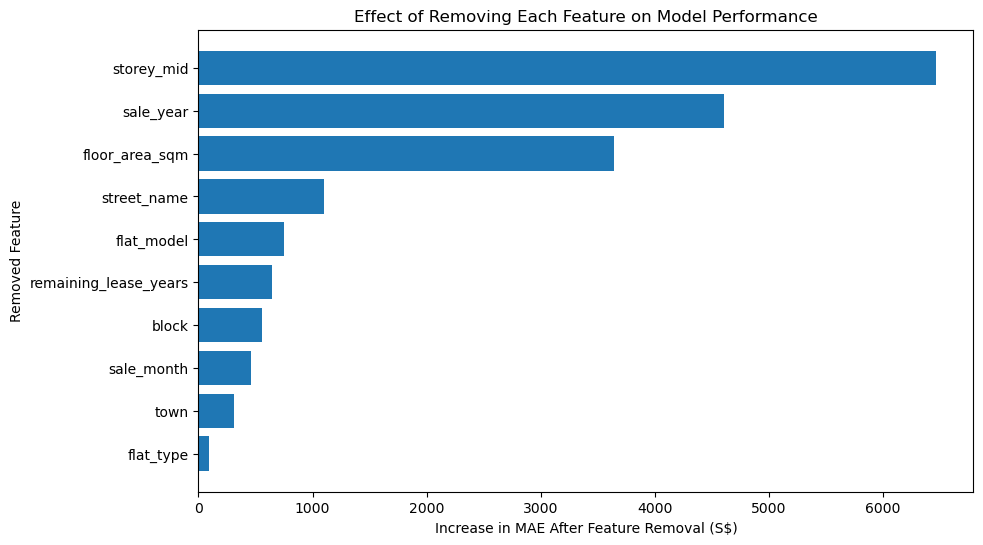

In [ ]:
# Exclude the control model from the feature-removal chart
feature_impact_df = feature_results_df[
    feature_results_df['Removed Feature'].notna()
].copy()

feature_impact_df = feature_impact_df.sort_values(
    by='MAE Change From Control',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_impact_df['Removed Feature'],
    feature_impact_df['MAE Change From Control']
)

plt.xlabel('Increase in MAE After Feature Removal (S$)')
plt.ylabel('Removed Feature')
plt.title('Effect of Removing Each Feature on Model Performance')
plt.ticklabel_format(
    style='plain',
    axis='x'
)

plt.show()

A larger increase in MAE indicates that the removed feature had a greater contribution to prediction performance.

`storey_mid` caused the largest increase in MAE, followed by `sale_year` and `floor_area_sqm`. This shows that these were the most influential features according to the controlled removal experiment.

# 6. Final Model Evaluation

## 6.1 Training and Testing Performance

The tuned Random Forest using all 10 candidate features is selected as the final model.

Its performance on the training and testing sets will be compared to determine whether it generalises well to unseen data. A substantially better training result than testing result may indicate overfitting.

In [ ]:
# Assign the selected tuned Random Forest as the final model
final_model = tuned_random_forest_pipeline

# Generate predictions for both datasets
final_train_predictions = final_model.predict(X_train)
final_test_predictions = final_model.predict(X_test)

# Compare training and testing performance
final_performance_df = pd.DataFrame([
    {
        'Dataset': 'Training',
        'MAE': mean_absolute_error(
            y_train,
            final_train_predictions
        ),
        'RMSE': np.sqrt(
            mean_squared_error(
                y_train,
                final_train_predictions
            )
        ),
        'R2': r2_score(
            y_train,
            final_train_predictions
        )
    },
    {
        'Dataset': 'Testing',
        'MAE': mean_absolute_error(
            y_test,
            final_test_predictions
        ),
        'RMSE': np.sqrt(
            mean_squared_error(
                y_test,
                final_test_predictions
            )
        ),
        'R2': r2_score(
            y_test,
            final_test_predictions
        )
    }
])

final_performance_df

,Dataset,MAE,RMSE,R2
0,Training,9619.479954,13982.155639,0.996773
1,Testing,26295.386009,38111.548237,0.976307
